In [43]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import shap
from scipy.sparse import hstack
from sklearn.metrics import confusion_matrix

### Pre-processing

In [2]:
DATA_PATH = '/home/eliyaah/big_data_proj' 
df = pd.read_csv(os.path.join(DATA_PATH, 'cleaned_news_dataset_w_derived_columns.csv'))

In [3]:
FEATURE_COLUMNS = [
    'exclamation_count_title', 'question_count_title', 'quotes_count_title',
    'ellipsis_count_title', 'hashtag_count_title', 'mention_count_title',
    'noun_ratio_title', 'verb_ratio_title', 'adj_ratio_title',
    'sentiment_polarity_title', 'sentiment_subjectivity_title',
    'capitalization_ratio_title', 'html_link_count_title',
    'exclamation_count_text', 'question_count_text', 'quotes_count_text',
    'ellipsis_count_text', 'hashtag_count_text', 'mention_count_text',
    'noun_ratio_text', 'verb_ratio_text', 'adj_ratio_text',
    'sentiment_polarity_text', 'sentiment_subjectivity_text',
    'capitalization_ratio_text', 'html_link_count_text'
]

In [4]:
def remove_reuters(text):
    if pd.isna(text):
        return ''
    return text.lower().replace('reuters', '').strip()

df['title'] = df['title'].apply(remove_reuters)
df['text'] = df['text'].apply(remove_reuters)

In [ ]:
# df['contains_reuters_title'] = df['title'].fillna('').str.lower().str.contains('reuters')
# print("🔍 Appearance in TITLE:")
# print(df.groupby('label')['contains_reuters_title'].mean())

In [ ]:
# df['contains_reuters_text'] = df['text'].fillna('').str.lower().str.contains('reuters')
# print("\n🔍 Appearance in TEXT:")
# print(df.groupby('label')['contains_reuters_text'].mean())

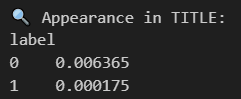

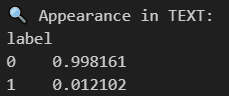
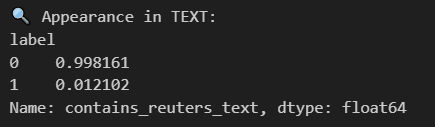

In [5]:
df['text'] = df['text'].str.replace(r'^[A-Z ,./\-a-z]*\s*\(Reuters\)\s*[-–—]*\s*', '', regex=True)

In [6]:
def prepare_text_versions(df):
    df = df.copy()
    df['text_title_only'] = df['title'].fillna('')
    df['text_body_only'] = df['text'].fillna('')
    df['text_combined'] = df['title'].fillna('') + ' [SEP] ' + df['text'].fillna('')
    return df
df = prepare_text_versions(df)

In [7]:
def prepare_data_splits(df, test_size=0.2, val_size=0.2):
    used_features = [col for col in FEATURE_COLUMNS if col in df.columns]
    
    train_val_df, test_df = train_test_split(df, test_size=test_size, stratify=df['label'], random_state=42)
    train_df, val_df = train_test_split(train_val_df, test_size=val_size, stratify=train_val_df['label'], random_state=42)
    
    return train_df, val_df, test_df, used_features

train_df, val_df, test_df, used_features = prepare_data_splits(df)

### Naive Bayes: Bag-of-Words and TF-IDF 

We trained a Multinomial Naive Bayes model using n-gram text features to classify news as real or fake, serving as a lightweight baseline for comparison

In [44]:
def run_naive_bayes_with_vectorizer(text_column, vectorizer_type='bow', return_model=False):
    if vectorizer_type == 'bow':
        vectorizer = CountVectorizer(max_features=10000, ngram_range=(1,2))
    elif vectorizer_type == 'tfidf':
        vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
    else:
        raise ValueError("vectorizer_type must be 'bow' or 'tfidf'")

    pipeline = Pipeline([
        ('vectorizer', vectorizer),
        ('clf', MultinomialNB())
    ])

    pipeline.fit(train_df[text_column], train_df['label'])
    y_pred = pipeline.predict(test_df[text_column])
    y_true = test_df['label']

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / (fp + tn)

    # full classification report
    report = classification_report(y_true, y_pred, output_dict=True)
    
    result = {
        'Config': f"{vectorizer_type.upper()}_{text_column.split('_')[1].capitalize()}",
        'F1': round(report['1']['f1-score'], 4),
        'Precision': round(report['1']['precision'], 4),
        'Recall': round(report['1']['recall'], 4),
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'FPR': round(fpr, 4)
    }

    if return_model:
        return result, pipeline
    else:
        return result

In [45]:
def plot_metrics_comparison_improved(results_df):
    """
    Plots F1, Precision, Recall, and Accuracy for each configuration.
    - X-axis: configuration names
    - Y-axis: metric scores (zoomed in to 0.85–1.0)
    - Each metric is shown in a different color
    - The highest score per metric is marked with a star (*) instead of a dot (o)
    - Lines connect the points for each metric
    """
    metrics = ['F1', 'Precision', 'Recall', 'Accuracy']
    colors = ['blue', 'orange', 'green', 'purple']

    plt.figure(figsize=(12, 6))
    x = np.arange(len(results_df))

    for i, metric in enumerate(metrics):
        y = results_df[metric]
        max_idx = y.idxmax()

        # Draw the full line with dots (o) for each metric
        plt.plot(x, y, color=colors[i], linewidth=2)

        # Plot dots for all points
        for j, val in enumerate(y):
            marker = '*' if j == max_idx else 'o'
            plt.plot(x[j], val, marker=marker, color=colors[i], markersize=12 if marker == '*' else 6)

        # Add one legend entry per metric (only once)
        plt.plot([], [], color=colors[i], marker='o', linestyle='-', label=metric)

    plt.xticks(x, results_df['Config'], rotation=45)
    plt.yticks(np.linspace(0.85, 1.00, 10))
    plt.ylim(0.87, 1.01)

    plt.ylabel("Score")
    plt.xlabel("Configuration")
    plt.title("Naive Bayes Performance Metrics per Configuration")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [46]:
text_columns = ['text_title_only', 'text_body_only', 'text_combined']
results = []

for col in text_columns:
    results.append(run_naive_bayes_with_vectorizer(col, vectorizer_type='bow'))
    results.append(run_naive_bayes_with_vectorizer(col, vectorizer_type='tfidf'))

results_df = pd.DataFrame(results)

           Config     F1  Precision  Recall  Accuracy    FPR
0       BOW_Title  0.936      0.924   0.950     0.942  0.064
1     TFIDF_Title  0.933      0.930   0.935     0.940  0.057
2        BOW_Body  0.936      0.950   0.921     0.943  0.039
3      TFIDF_Body  0.924      0.937   0.912     0.933  0.050
4    BOW_Combined  0.955      0.954   0.956     0.960  0.037
5  TFIDF_Combined  0.944      0.944   0.943     0.950  0.045


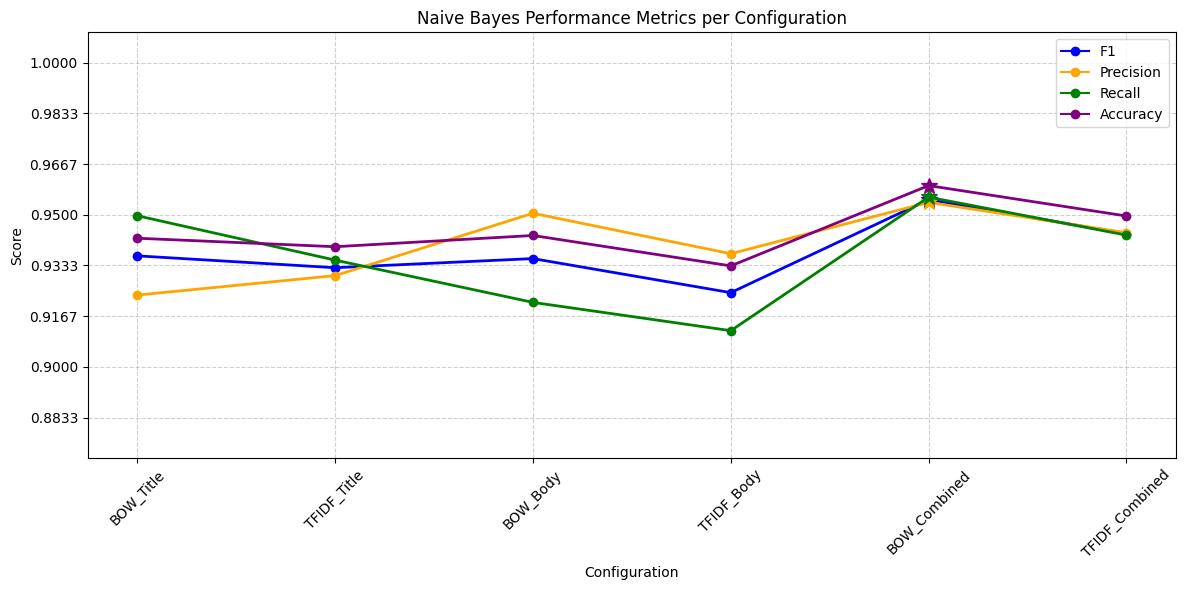

In [47]:
print(results_df.round(3))
plot_metrics_comparison_improved(results_df)

In [20]:
def get_top_features_naive_bayes(model, top_k=20):
    vectorizer = model.named_steps['vectorizer']
    clf = model.named_steps['clf']
    feature_names = vectorizer.get_feature_names_out()

    importance = clf.feature_log_prob_[1] - clf.feature_log_prob_[0]

    top_fake_indices = np.argsort(importance)[::-1][:top_k]
    top_fake = pd.DataFrame({
        'Feature': [feature_names[i] for i in top_fake_indices],
        'Score': [importance[i] for i in top_fake_indices],
        'Label': ['Fake (1)'] * top_k
    })

    top_real_indices = np.argsort(importance)[:top_k]
    top_real = pd.DataFrame({
        'Feature': [feature_names[i] for i in top_real_indices],
        'Score': [importance[i] for i in top_real_indices],
        'Label': ['Real (0)'] * top_k
    })

    return pd.concat([top_fake, top_real], ignore_index=True)

In [21]:
_, nb_model = run_naive_bayes_with_vectorizer('text_combined', vectorizer_type='bow', return_model=True)
top_features_df = get_top_features_naive_bayes(nb_model)
print(top_features_df)

                 Feature     Score     Label
0         featured image  8.619962  Fake (1)
1              image via  8.422104  Fake (1)
2            twitter com  8.221071  Fake (1)
3            pic twitter  8.170682  Fake (1)
4           getty images  7.974702  Fake (1)
5                  https  7.810216  Fake (1)
6               https co  7.506190  Fake (1)
7                  getty  7.309453  Fake (1)
8              video sep  7.163379  Fake (1)
9         screen capture  6.905896  Fake (1)
10                   pic  6.812729  Fake (1)
11                21wire  6.775303  Fake (1)
12  2017 realdonaldtrump  6.768762  Fake (1)
13          century wire  6.646046  Fake (1)
14                  quot  6.501003  Fake (1)
15                    js  6.464318  Fake (1)
16           via youtube  6.250913  Fake (1)
17             via getty  6.237609  Fake (1)
18        below featured  6.114230  Fake (1)
19                flickr  6.049018  Fake (1)
20              rohingya -7.159521  Real (0)
21        

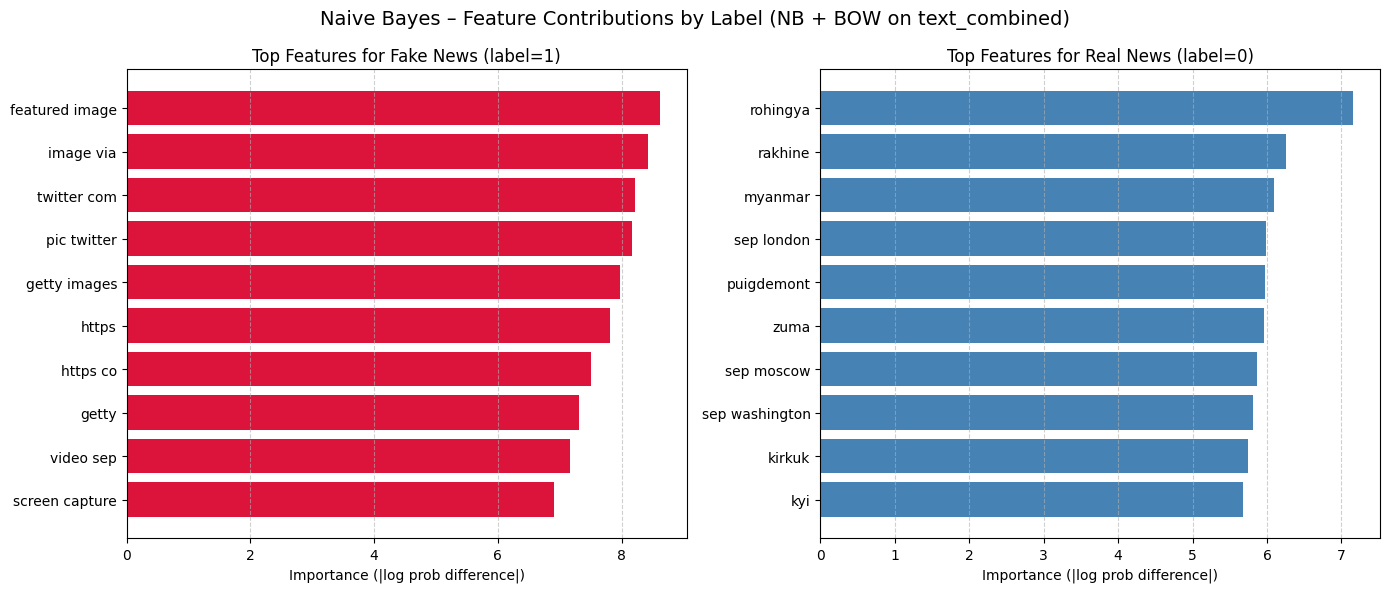

In [22]:
def plot_top_features_naive_bayes_dual(top_features_df, config_label="NB + BOW on text_combined"):
    top_features_df['AbsScore'] = top_features_df['Score'].abs()
    fake_df = top_features_df[top_features_df['Label'] == 'Fake (1)'].head(10)
    real_df = top_features_df[top_features_df['Label'] == 'Real (0)'].head(10)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Fake news plot
    axes[0].barh(fake_df['Feature'][::-1], fake_df['AbsScore'][::-1], color='crimson')
    axes[0].set_title("Top Features for Fake News (label=1)")
    axes[0].set_xlabel("Importance (|log prob difference|)")
    axes[0].grid(True, axis='x', linestyle='--', alpha=0.6)

    # Real news plot
    axes[1].barh(real_df['Feature'][::-1], real_df['AbsScore'][::-1], color='steelblue')
    axes[1].set_title("Top Features for Real News (label=0)")
    axes[1].set_xlabel("Importance (|log prob difference|)")
    axes[1].grid(True, axis='x', linestyle='--', alpha=0.6)

    fig.suptitle(f"Naive Bayes – Feature Contributions by Label ({config_label})", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_top_features_naive_bayes_dual(top_features_df)

All features are textual n-grams that created authomatically by the CountVectorizer

### Random Forest: Bag-of-Words and TF-IDF (Using Features)

In [48]:
def run_random_forest_with_vectorizer(text_column, vectorizer_type='bow', return_model=False):
    if vectorizer_type == 'bow':
        vectorizer = CountVectorizer(max_features=10000, ngram_range=(1,2))
    elif vectorizer_type == 'tfidf':
        vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
    else:
        raise ValueError("vectorizer_type must be 'bow' or 'tfidf'")

    preprocessor = ColumnTransformer([
        ('text', vectorizer, text_column),
        ('features', StandardScaler(), FEATURE_COLUMNS)
    ])

    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
    ])

    pipeline.fit(train_df, train_df['label'])
    y_pred = pipeline.predict(test_df)
    y_true = test_df['label']

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / (fp + tn)

    report = classification_report(y_true, y_pred, output_dict=True)

    result = {
        'Config': f"RF_{vectorizer_type.upper()}_{text_column.split('_')[1].capitalize()}",
        'F1': round(report['1']['f1-score'], 4),
        'Precision': round(report['1']['precision'], 4),
        'Recall': round(report['1']['recall'], 4),
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'FPR': round(fpr, 4)
    }
    if return_model:
        return result, pipeline
    else:
        return result

In [49]:
def plot_metrics_comparison_rf(results_df):
    """
    Visualizes F1, Precision, Recall, and Accuracy for Random Forest results.
    - X-axis: configuration names
    - Y-axis: metric scores (zoomed in to 0.85–1.0)
    - Each metric is shown in a different color
    - The highest score per metric is marked with a star (*) instead of a dot (o)
    - Lines connect the points for each metric
    """
    metrics = ['F1', 'Precision', 'Recall', 'Accuracy']
    colors = ['blue', 'orange', 'green', 'purple']

    plt.figure(figsize=(12, 6))
    x = np.arange(len(results_df))

    for i, metric in enumerate(metrics):
        y = results_df[metric]
        max_idx = y.idxmax()

        # Draw the full line with dots (o) for each metric
        plt.plot(x, y, color=colors[i], linewidth=2)

        # Plot individual markers (o or *)
        for j, val in enumerate(y):
            marker = '*' if j == max_idx else 'o'
            plt.plot(x[j], val, marker=marker, color=colors[i], markersize=12 if marker == '*' else 6)

        # Add one legend entry per metric
        plt.plot([], [], color=colors[i], marker='o', linestyle='-', label=metric)

    plt.xticks(x, results_df['Config'], rotation=45)
    plt.yticks(np.linspace(0.97, 1.00, 7))
    plt.ylim(0.97, 1.005)
    plt.ylabel("Score")
    plt.xlabel("Configuration")
    plt.title("Random Forest Performance Metrics per Configuration")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


In [50]:
text_columns = ['text_title_only', 'text_body_only', 'text_combined']
rf_results = []

for col in text_columns:
    rf_results.append(run_random_forest_with_vectorizer(col, vectorizer_type='bow'))
    rf_results.append(run_random_forest_with_vectorizer(col, vectorizer_type='tfidf'))

rf_results_df = pd.DataFrame(rf_results)
print(rf_results_df.to_string(index=False))

           Config     F1  Precision  Recall  Accuracy    FPR
     RF_BOW_Title 0.9843     0.9914  0.9773    0.9861 0.0068
   RF_TFIDF_Title 0.9852     0.9950  0.9756    0.9868 0.0040
      RF_BOW_Body 0.9936     0.9985  0.9887    0.9943 0.0012
    RF_TFIDF_Body 0.9945     0.9979  0.9910    0.9951 0.0017
  RF_BOW_Combined 0.9946     0.9977  0.9916    0.9952 0.0019
RF_TFIDF_Combined 0.9948     0.9974  0.9921    0.9953 0.0021


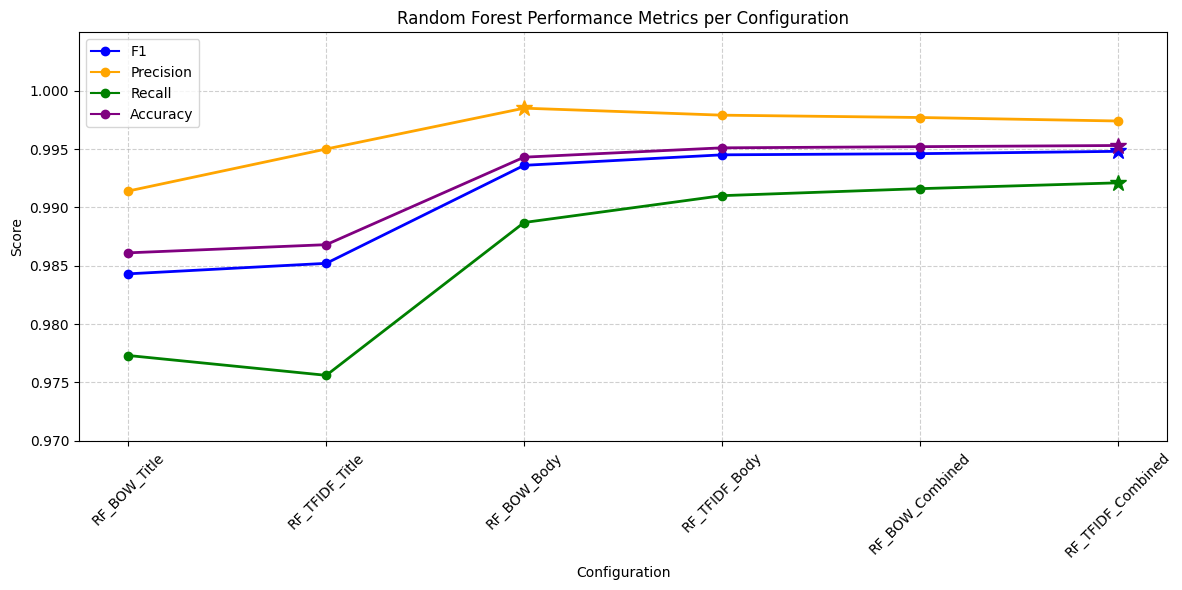

In [32]:
plot_metrics_comparison_rf(rf_results_df)

### XGBoost: Bag-of-Words and TF-IDF (Using Features)

In [9]:
def clean_feature_name(name):
    if name.startswith("text__"):
        word = name.replace("text__", "")
        return f"'{word}'"
    elif name.startswith("features__"):
        col = name.replace("features__", "")
        col = col.replace("_", " ").capitalize()
        return f"{col}"
    else:
        return name

In [10]:
def run_xgboost_with_vectorizer(text_column, vectorizer_type='bow', return_model=False):
    if vectorizer_type == 'bow':
        vectorizer = CountVectorizer(max_features=10000, ngram_range=(1,2))
    elif vectorizer_type == 'tfidf':
        vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
    else:
        raise ValueError("vectorizer_type must be 'bow' or 'tfidf'")

    preprocessor = ColumnTransformer([
        ('text', vectorizer, text_column),
        ('features', StandardScaler(), FEATURE_COLUMNS)
    ])

    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('clf', XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'))
    ])

    pipeline.fit(train_df, train_df['label'])
    y_pred = pipeline.predict(test_df)
    y_true = test_df['label']

    report = classification_report(y_true, y_pred, output_dict=True)

    result = {
        'Config': f"XGB_{vectorizer_type.upper()}_{text_column.split('_')[1].capitalize()}",
        'F1': round(report['1']['f1-score'], 4),
        'Precision': round(report['1']['precision'], 4),
        'Recall': round(report['1']['recall'], 4),
        'Accuracy': round(accuracy_score(y_true, y_pred), 4)
    }

    if return_model:
        return result, pipeline
    else:
        return result

In [23]:
def plot_metrics_comparison_xgb(results_df):
    """
    Visualizes F1, Precision, Recall, and Accuracy for XGBoost results.
    - X-axis: configuration names
    - Y-axis: metric scores (zoomed in to 0.85–1.0)
    - Each metric is shown in a different color
    - The highest score per metric is marked with a star (*) instead of a dot (o)
    - Lines connect the points for each metric
    """
    metrics = ['F1', 'Precision', 'Recall', 'Accuracy']
    colors = ['blue', 'orange', 'green', 'purple']

    plt.figure(figsize=(12, 6))
    x = np.arange(len(results_df))

    for i, metric in enumerate(metrics):
        y = results_df[metric]
        max_idx = y.idxmax()

        # Draw the full line with dots (o) for each metric
        plt.plot(x, y, color=colors[i], linewidth=2)

        # Plot individual markers (o or *)
        for j, val in enumerate(y):
            marker = '*' if j == max_idx else 'o'
            plt.plot(x[j], val, marker=marker, color=colors[i], markersize=12 if marker == '*' else 6)

        # Add one legend entry per metric
        plt.plot([], [], color=colors[i], marker='o', linestyle='-', label=metric)

    plt.xticks(x, results_df['Config'])
    plt.yticks(np.linspace(0.97, 1.00, 7))
    plt.ylim(0.97, 1.005)
    plt.ylabel("Score")
    plt.xlabel("Configuration")
    plt.title("XGBoost Performance Metrics per Configuration")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [24]:
text_columns = ['text_title_only', 'text_body_only', 'text_combined']
xgb_results = []

for col in text_columns:
    xgb_results.append(run_xgboost_with_vectorizer(col, vectorizer_type='bow'))
    xgb_results.append(run_xgboost_with_vectorizer(col, vectorizer_type='tfidf'))

xgb_results_df = pd.DataFrame(xgb_results)
print(xgb_results_df.to_string(index=False))

/home/eliyaah/.conda/envs/unsloth_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [13:16:01] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/eliyaah/.conda/envs/unsloth_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [13:16:43] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/eliyaah/.conda/envs/unsloth_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [13:17:41] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/eliyaah/.conda/envs/unsloth_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [13:18:41] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fo

            Config     F1  Precision  Recall  Accuracy
     XGB_BOW_Title 0.9872     0.9892  0.9852    0.9885
   XGB_TFIDF_Title 0.9864     0.9889  0.9840    0.9879
      XGB_BOW_Body 0.9983     0.9983  0.9983    0.9984
    XGB_TFIDF_Body 0.9981     0.9983  0.9980    0.9983
  XGB_BOW_Combined 0.9991     0.9985  0.9997    0.9992
XGB_TFIDF_Combined 0.9980     0.9977  0.9983    0.9982


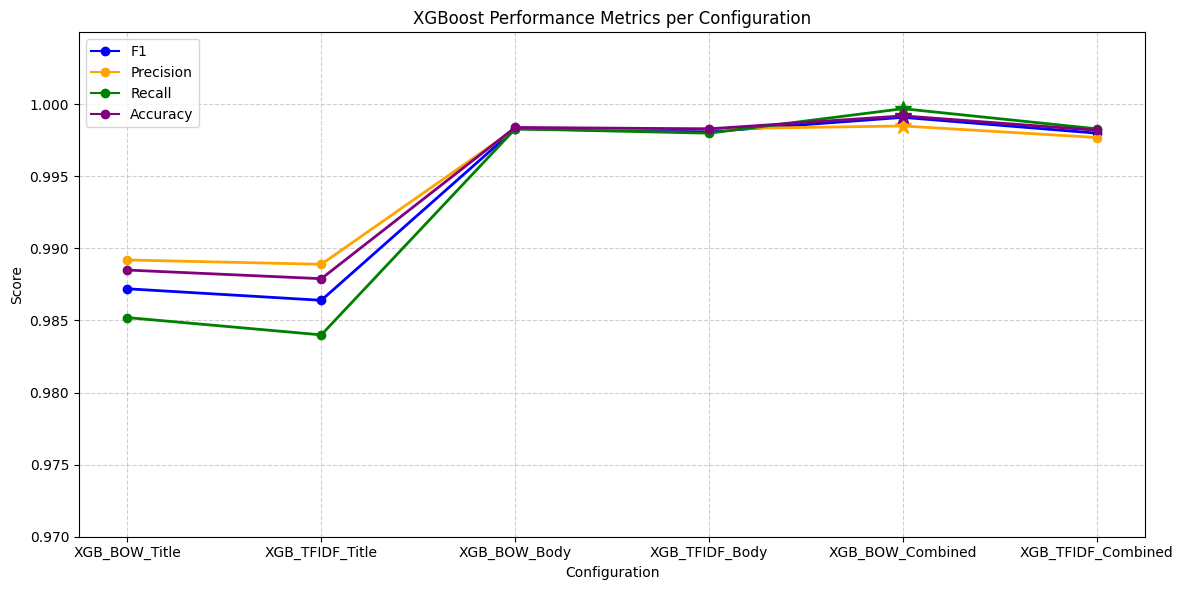

In [25]:
plot_metrics_comparison_xgb(xgb_results_df)

In [ ]:
import textwrap

def wrap_feature_name(name, width=20):
    return "\n".join(textwrap.wrap(name, width=width))


/home/eliyaah/.conda/envs/unsloth_env/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [13:43:39] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
 99%|===================| 24326/24574 [01:22<00:00]        

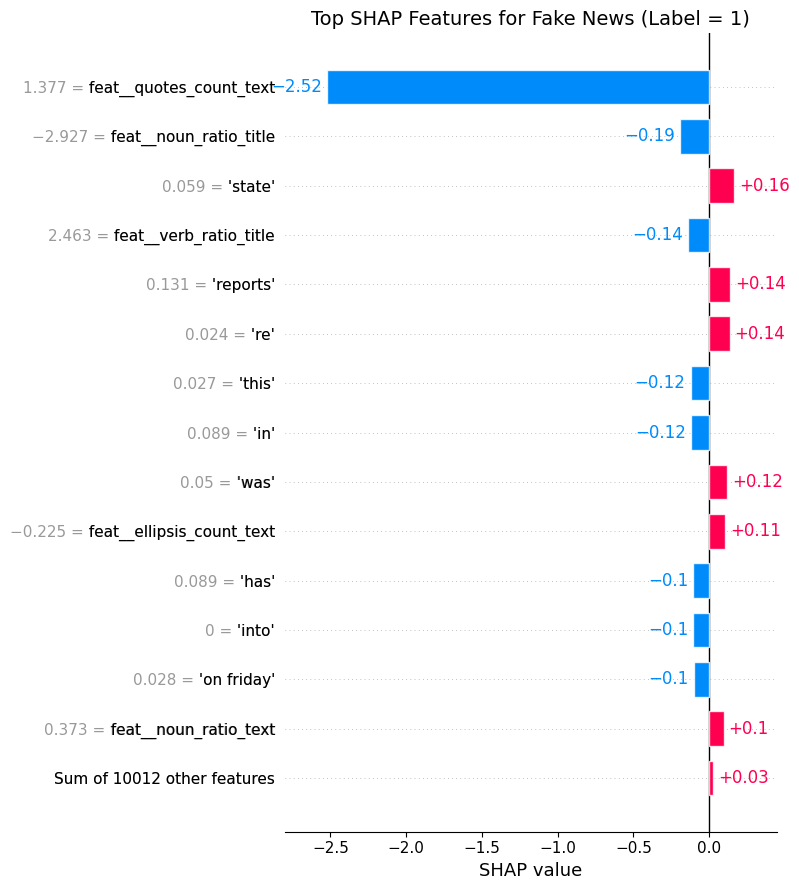

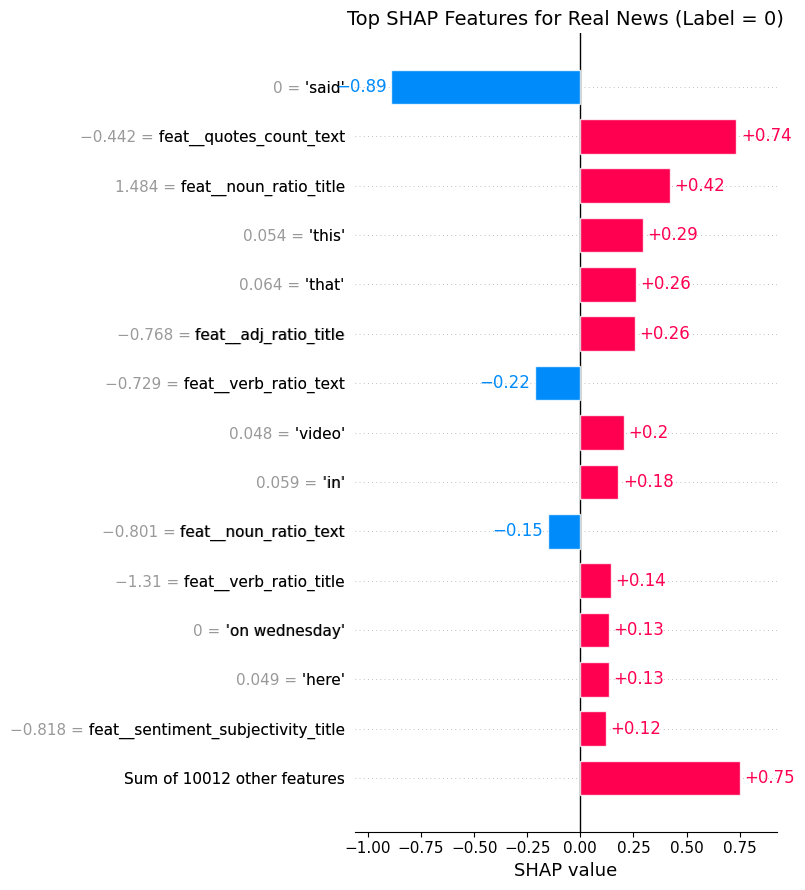

In [28]:
_, pipeline = run_xgboost_with_vectorizer('text_combined', vectorizer_type='tfidf', return_model=True)

vectorizer = pipeline.named_steps['preprocess'].transformers_[0][1]
text_column = pipeline.named_steps['preprocess'].transformers_[0][2]
scaler = pipeline.named_steps['preprocess'].transformers_[1][1]
clf = pipeline.named_steps['clf']

X_text_sparse = vectorizer.transform(train_df[text_column])
X_num = scaler.transform(train_df[FEATURE_COLUMNS])
X_all_sparse = hstack([X_text_sparse, X_num])
X_all_dense = X_all_sparse.toarray()

text_features = [f"text__{f}" for f in vectorizer.get_feature_names_out()]
num_features = [f"feat__{col}" for col in FEATURE_COLUMNS]
full_feature_names = text_features + num_features

clean_names = [clean_feature_name(name) for name in full_feature_names]
# explainer = shap.Explainer(clf)
explainer = shap.Explainer(clf, X_all_dense, feature_names=clean_names)

shap_values = explainer(X_all_dense)

shap.plots.bar(shap_values[1], max_display=15, show=False)
plt.title("Top SHAP Features for Fake News (Label = 1)", fontsize=14)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

shap.plots.bar(shap_values[0], max_display=15, show=False)
plt.title("Top SHAP Features for Real News (Label = 0)", fontsize=14)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()